# 1. Exploratory Data Analysis

## Objective

The objective of this project is to analyze a credit card customer portfolio, identify distinct customer segments, and predict customer attrition using machine learning methods. The analysis combines unsupervised learning for customer segmentation with supervised learning for churn prediction.

Exploratory Data Analysis (EDA) is the first stage of the analytical process. Its purpose is to understand the structure and characteristics of the dataset, examine variable distributions, assess data quality, and investigate relationships between customer attributes and attrition.

The findings from this stage provide context for the subsequent customer segmentation and churn prediction tasks.

## Analytical Approach

The project consists of three main stages:

1. **Exploratory Data Analysis** — examining the dataset, its variables, distributions, and relationships with customer attrition.
2. **Customer Segmentation** — applying K-Means clustering to identify groups of customers with similar financial and transactional characteristics.
3. **Churn Prediction** — developing a logistic regression model to estimate customer attrition risk, using feature transformations including Optimal Binning.

The analytical process was implemented in Python using Jupyter Notebook. The main libraries include pandas, NumPy, Matplotlib, Seaborn, scikit-learn, SciPy, statsmodels, and OptBinning.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the data

In [3]:
df = pd.read_csv('BankChurners.csv')

df = df.set_index("CLIENTNUM")
df = df.drop(
    columns=[
        "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
        "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2",
    ],
    errors="raise",
)

df.head()


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
CLIENTNUM,,,,,,,,,,,,,,,,,,,,
768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


# Dataset overview

In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 10127 entries, 768805383 to 714337233
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  str    
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  str    
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  str    
 5   Marital_Status            10127 non-null  str    
 6   Income_Category           10127 non-null  str    
 7   Card_Category             10127 non-null  str    
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Open_T

In [5]:
df.isnull().any()

Attrition_Flag              False
Customer_Age                False
Gender                      False
Dependent_count             False
Education_Level             False
Marital_Status              False
Income_Category             False
Card_Category               False
Months_on_book              False
Total_Relationship_Count    False
Months_Inactive_12_mon      False
Contacts_Count_12_mon       False
Credit_Limit                False
Total_Revolving_Bal         False
Avg_Open_To_Buy             False
Total_Amt_Chng_Q4_Q1        False
Total_Trans_Amt             False
Total_Trans_Ct              False
Total_Ct_Chng_Q4_Q1         False
Avg_Utilization_Ratio       False
dtype: bool

# Numerical variables

In [6]:
df.describe()

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [7]:
#współczynnik zmienności dla zmiennych numerycznych

# lista zmiennych ilościowych:
quant_vars = df.select_dtypes(include=['int64', 'float64']).columns

# obliczanie współczynnika zmienności dla każdej zmiennej ilościowej:
cv = df[quant_vars].std() / df[quant_vars].mean() * 100
print(cv)

Customer_Age                 17.305230
Dependent_count              55.362142
Months_on_book               22.228695
Total_Relationship_Count     40.770496
Months_Inactive_12_mon       43.167460
Contacts_Count_12_mon        45.054261
Credit_Limit                105.292231
Total_Revolving_Bal          70.087503
Avg_Open_To_Buy             121.709939
Total_Amt_Chng_Q4_Q1         28.845248
Total_Trans_Amt              77.135847
Total_Trans_Ct               36.190322
Total_Ct_Chng_Q4_Q1          33.428617
Avg_Utilization_Ratio       100.290264
dtype: float64


In [11]:
df[quant_vars].info()

<class 'pandas.DataFrame'>
Index: 10127 entries, 768805383 to 714337233
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Dependent_count           10127 non-null  int64  
 1   Months_on_book            10127 non-null  int64  
 2   Total_Relationship_Count  10127 non-null  int64  
 3   Months_Inactive_12_mon    10127 non-null  int64  
 4   Contacts_Count_12_mon     10127 non-null  int64  
 5   Credit_Limit              10127 non-null  float64
 6   Total_Revolving_Bal       10127 non-null  int64  
 7   Total_Amt_Chng_Q4_Q1      10127 non-null  float64
 8   Total_Trans_Ct            10127 non-null  int64  
 9   Total_Ct_Chng_Q4_Q1       10127 non-null  float64
 10  Avg_Utilization_Ratio     10127 non-null  float64
 11  Avg_Transaction_Value     10127 non-null  float64
dtypes: float64(5), int64(7)
memory usage: 1.0 MB


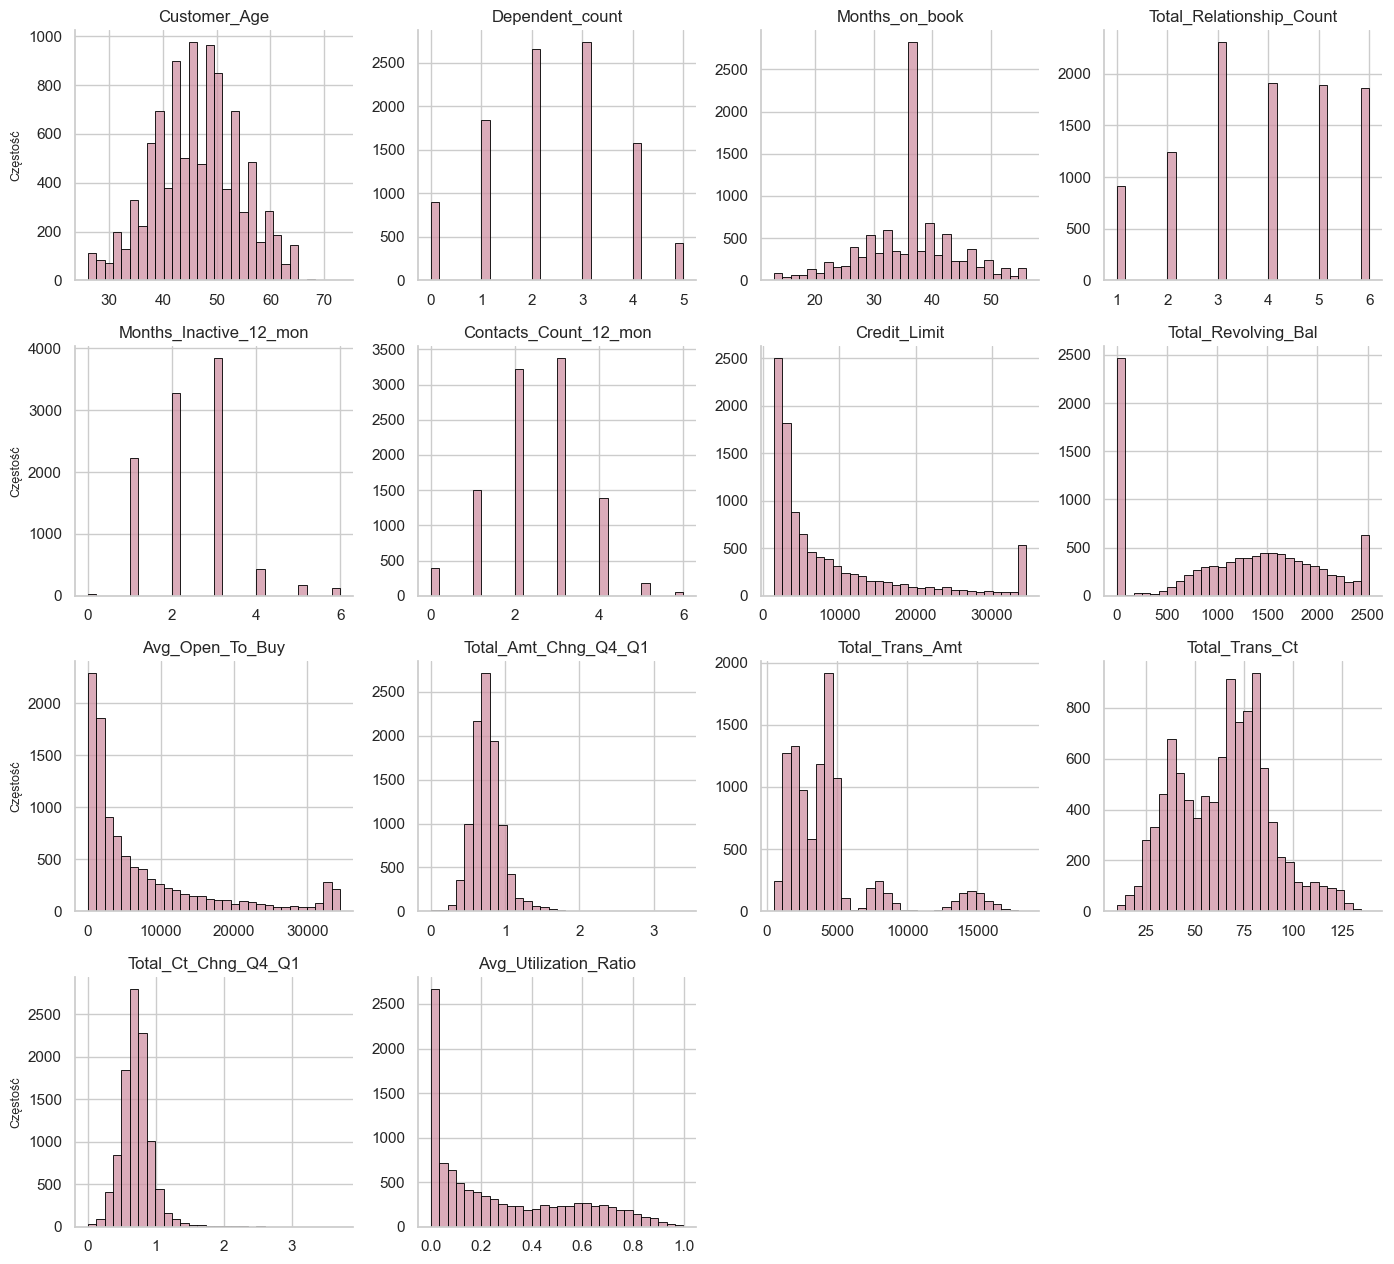

In [ ]:
# przekształcamy dane do formatu long (potrzebne do FacetGrid)
df_long = df[quant_vars].melt(var_name='Zmienna', value_name='Wartość')
sns.set_theme(style="whitegrid")
base_color = sns.cubehelix_palette(n_colors=5, dark=0.4, light=0.9)[2]

g = sns.FacetGrid(
    df_long,
    col='Zmienna',
    col_wrap=4, # ile kolumn w siatce
    height=3.2,
    aspect=1.1,
    sharex=False, # każda zmienna może mieć inną skalę X
    sharey=False
)

g.map(sns.histplot, 'Wartość', bins=30, color=base_color, edgecolor='black')

g.set_titles('{col_name}',fontsize=10)
g.set_axis_labels('', 'Częstość', fontsize=9)
g.tight_layout()
plt.show()

* **Symmetric & Demographics Features (`Customer_Age`, `Months_on_book`, `Total_Amt_Chng_Q4_Q1`, `Total_Ct_Chng_Q4_Q1`):**  
  Exhibit relatively symmetrical distributions with low coefficient of variation (17%–22%), indicating high cohort homogeneity. Average customer age is ~46 years, with a notable mode of 36 months for bank tenure. Quarterly change metrics show symmetry but contain numerous outliers.

* **Highly Right-Skewed Financial Metrics (`Credit_Limit`, `Avg_Open_To_Buy`, `Avg_Utilization_Ratio`):**  
  Strongly right-skewed with high variability (CV near/above 100%) and extensive outliers. Most customers hold lower limits, but a long tail extends to $34k+, reflecting significant portfolio diversity.

* **Multimodal & Structural Patterns (`Total_Trans_Amt`, `Total_Trans_Ct`, `Total_Revolving_Bal`):**  
  Transaction metrics display multiple peaks, suggesting distinct natural customer segments. `Total_Revolving_Bal` features a prominent zero-inflation peak (customers paying in full vs. revolving debt).

* **Discrete Metrics (`Dependent_count`, `Total_Relationship_Count`, `Contacts_Count_12_mon`, `Months_Inactive_12_mon`):**  
  Take few integer values (<= 7) with moderate variability (40%–55%) and minor outliers.


#### Key Preprocessing Strategy & Modeling Takeaways
* **Outlier Handling:** Outliers represent legitimate extreme customer behaviors rather than measurement errors, so they are **retained** to preserve full signal.
* **Scaling:** Feature scaling (Standardization) is essential for distance-based algorithms like K-Means due to large differences in feature scales and variances.
* **Binning / Categorization:** For Logistic Regression, discretizing multimodal features, heavily skewed variables, or low-cardinality discrete integers into categorical bins will help respect linearity assumptions and capture non-linear churn dynamics.

/Users/emilia/miniconda3/envs/thesis_env/lib/python3.12/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


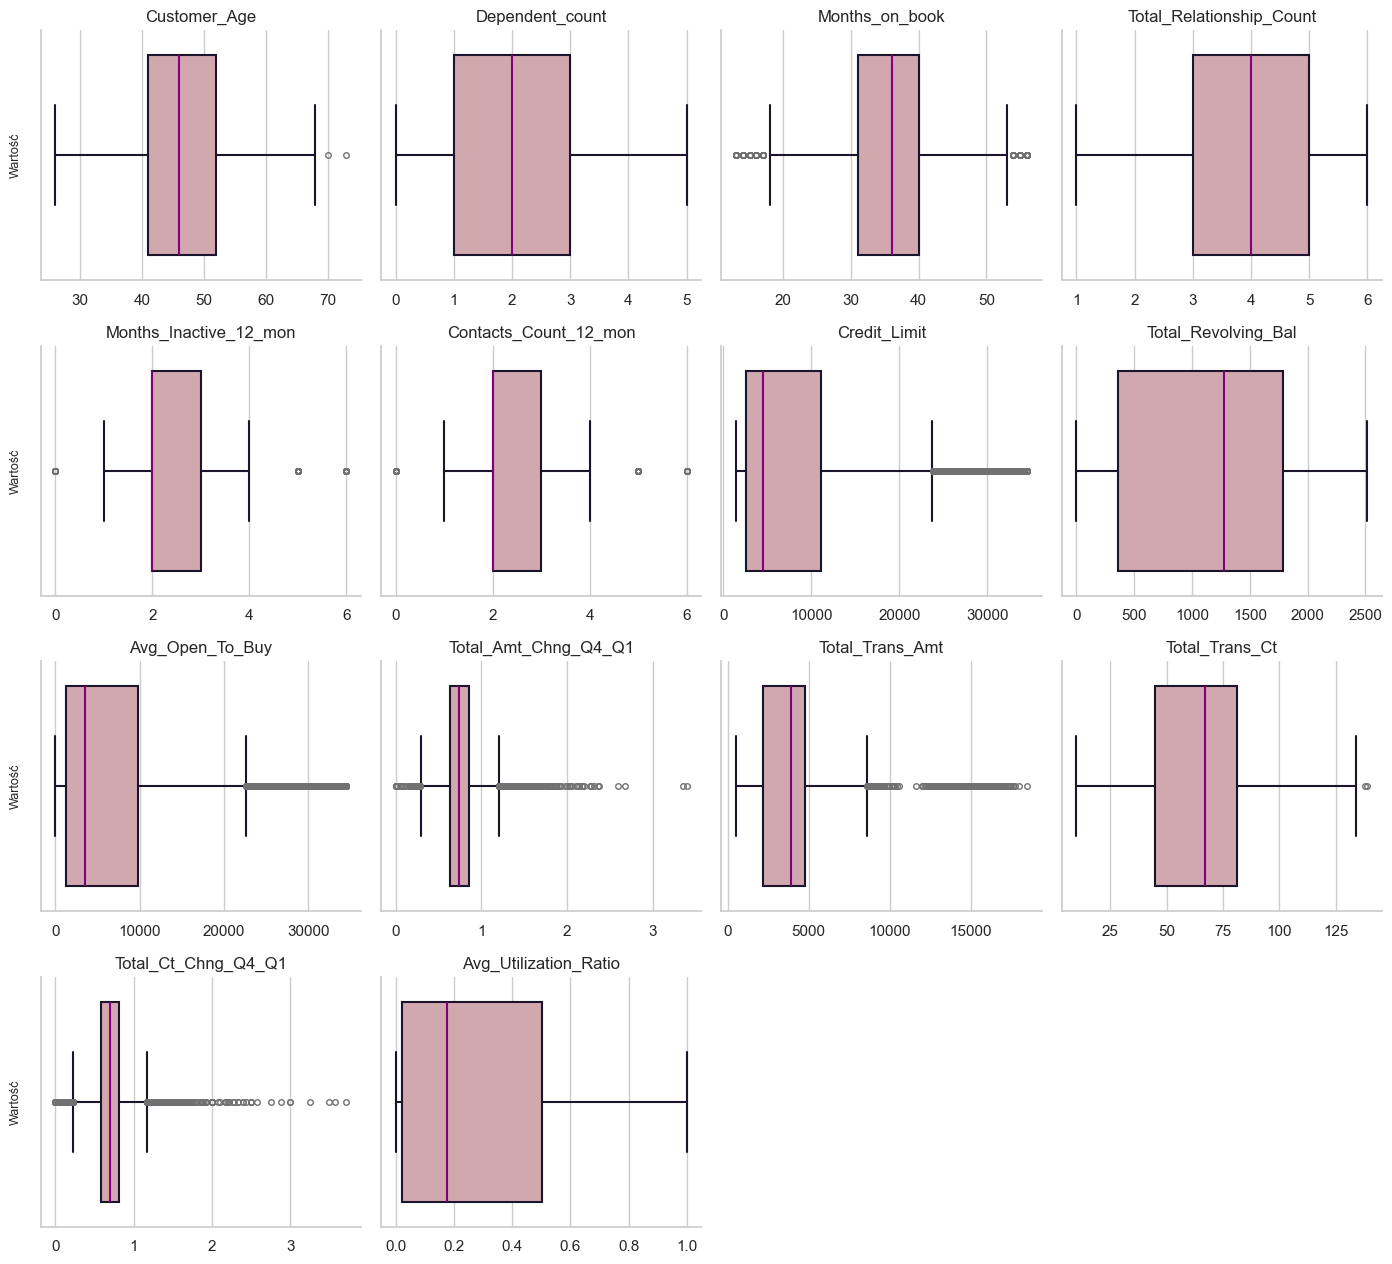

In [64]:
sns.set_theme(style="whitegrid")
base_palette_box = sns.cubehelix_palette(n_colors=5, dark=0.1, light=0.9)

g = sns.FacetGrid(
    df_long,
    col='Zmienna',
    col_wrap=4,
    height=3.2,
    aspect=1.1,
    sharex=False,
    sharey=False
)

g.map(sns.boxplot, 'Wartość',
      color=base_palette_box[1],
      boxprops=dict(edgecolor=base_palette_box[4],),
      medianprops=dict(color='purple'),
      whiskerprops=dict(color=base_palette_box[4]),
      capprops=dict(color=base_palette_box[4]),
      fliersize=4,
      linewidth=1.5)

g.set_titles('{col_name}', fontsize=10)
g.set_axis_labels('', 'Wartość', fontsize=9)
g.tight_layout()
plt.show()

# Categorial variables

In [18]:
categorial = df[['Attrition_Flag', 'Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']]

for col in categorial.columns:
    print(f'{col}:\n{categorial[col].value_counts()}\n')

Attrition_Flag:
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

Gender:
Gender
F    5358
M    4769
Name: count, dtype: int64

Education_Level:
Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64

Marital_Status:
Marital_Status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64

Income_Category:
Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64

Card_Category:
Card_Category
Blue        9436
Silver       555
Gold         116
Platinum      20
Name: count, dtype: int64



## Initial Data Quality Assessment

The initial inspection confirmed the dataset dimensions, variable types, and completeness of observations. No direct missing values were identified at this stage. However, some categorical variables contained an `Unknown` category, indicating that the corresponding customer information was unavailable.

These observations were retained because the absence of customer information may itself be relevant to understanding customer profiles and reflects a common characteristic of real-world CRM data.

## Relationship with churn

In [ ]:
# Rozkład zmiennej zależnej
df['Attrition_Flag'].value_counts(normalize=True)


Attrition_Flag
Existing Customer    0.83934
Attrited Customer    0.16066
Name: proportion, dtype: float64

In [ ]:
# Tabele krzyżowe z churn
for col in ['Gender', 'Education_Level', 'Marital_Status',
            'Income_Category', 'Card_Category']:
    
    print(f"\n=== {col} ===")
    print(pd.crosstab(df[col], df['Attrition_Flag']))


=== Gender ===
Attrition_Flag  Attrited Customer  Existing Customer
Gender                                              
F                             930               4428
M                             697               4072

=== Education_Level ===
Attrition_Flag   Attrited Customer  Existing Customer
Education_Level                                      
College                        154                859
Doctorate                       95                356
Graduate                       487               2641
High School                    306               1707
Post-Graduate                   92                424
Uneducated                     237               1250
Unknown                        256               1263

=== Marital_Status ===
Attrition_Flag  Attrited Customer  Existing Customer
Marital_Status                                      
Divorced                      121                627
Married                       709               3978
Single                   

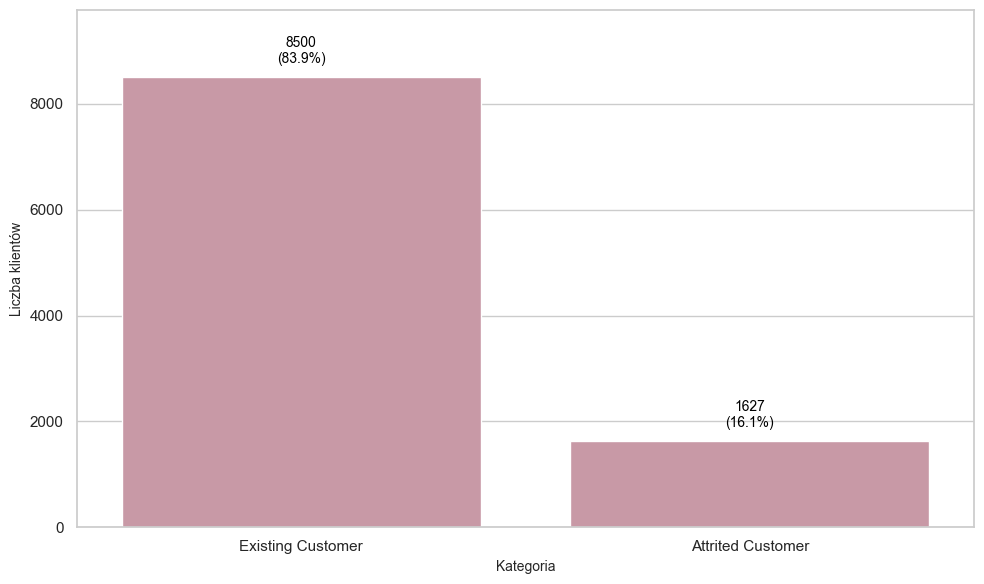

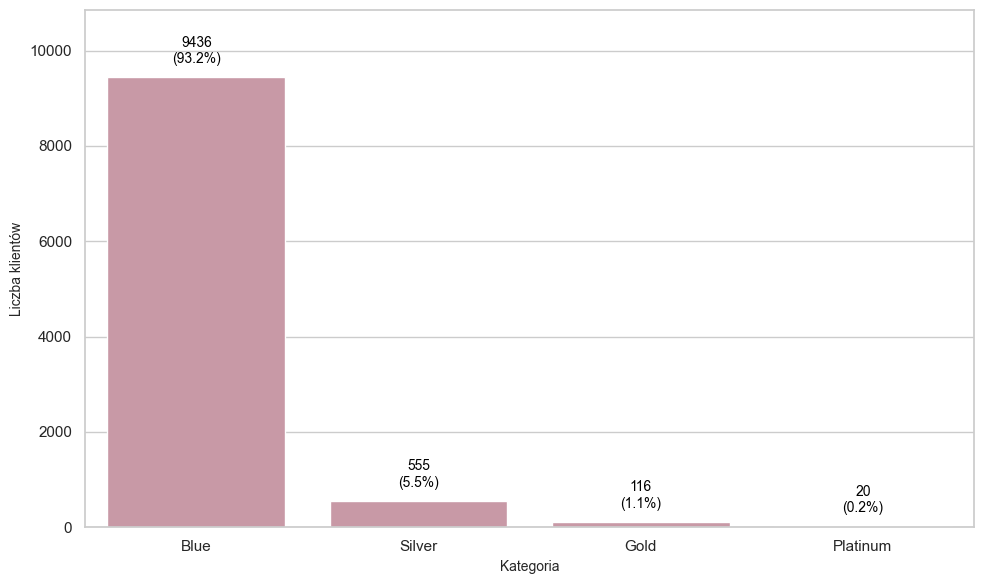

In [ ]:
# Ustawienia stylu i koloru
sns.set_theme(style="whitegrid")
base_color = sns.cubehelix_palette(n_colors=5, dark=0.4, light=0.9)[2]

# Generowanie pionowych wykresów słupkowych
zmienne_pionowe = ['Attrition_Flag', 'Card_Category']

for kolumna in zmienne_pionowe:
    plt.figure(figsize=(10, 6)) # Nowe płótno dla każdego wykresu
    
    total_count = len(df[kolumna].dropna())
    order = df[kolumna].value_counts().index
    
    # Przypisanie kolumny do osi 'x' generuje wykres pionowy
    ax = sns.countplot(
        data=df, 
        x=kolumna, 
        order=order,
        color=base_color 
    )
    
    # Zwiększenie limitu osi Y o 15% na etykiety
    max_height = max([p.get_height() for p in ax.patches])
    ax.set_ylim(0, max_height * 1.15) 
    
    # Dodawanie etykiet (liczebność + procent) NAD słupkami
    for p in ax.patches:
        count = int(p.get_height())
        percentage = f'{100 * count / total_count:.1f}%'
        
        ax.annotate(f'{count}\n({percentage})', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', 
                    fontsize=10, color='black', 
                    xytext=(0, 8), # Odsunięcie w górę
                    textcoords='offset points')
    
    plt.xlabel('Kategoria', fontsize=10)
    plt.ylabel('Liczba klientów', fontsize=10)
    
    plt.tight_layout()
    plt.show()

Attrition_flag - problem with not balanced classes, potential solution includes lowering cut-off threshold for classification

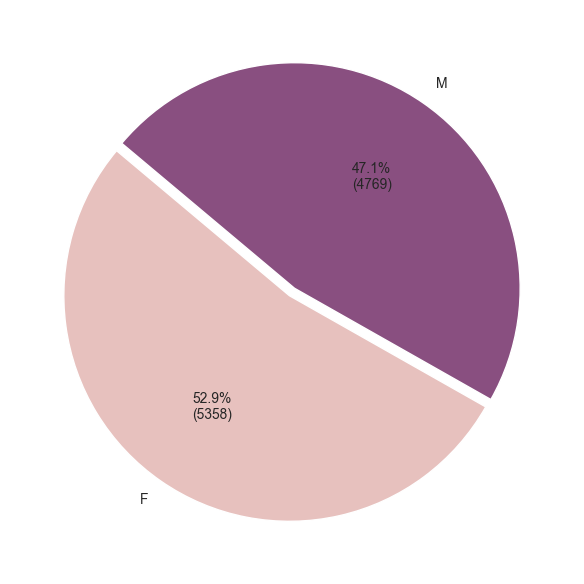

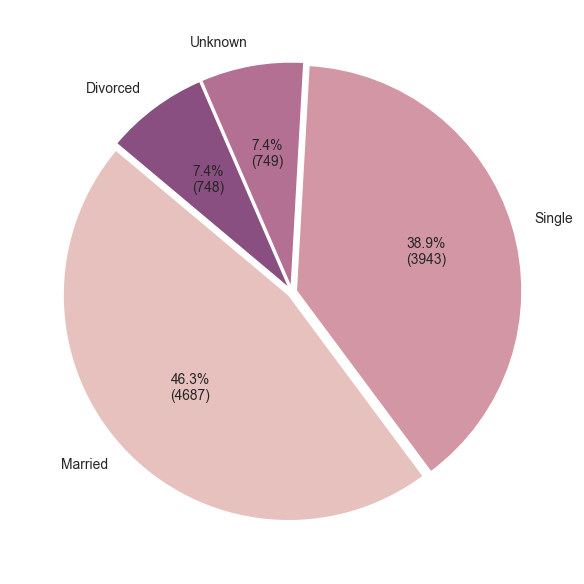

In [51]:
sns.set_theme(style="whitegrid")

# Funkcja do formatowania etykiet (procent + liczebność)
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({val})'
    return my_autopct


zmienne_kolowe = ['Gender', 'Marital_Status']

#generowanie wykresów w pętli
for kolumna in zmienne_kolowe:
    # Przygotowanie danych dla konkretnej zmiennej
    counts = df[kolumna].value_counts()
    labels = counts.index
    sizes = counts.values
    
    # Generowanie palety cubehelix dopasowanej do liczby kategorii w danej zmiennej
    pie_colors = sns.cubehelix_palette(n_colors=len(sizes), dark=0.4, light=0.8)
    
    # Tworzenie nowego, ODDZIELNEGO rysunku dla każdego wykresu
    plt.figure(figsize=(8, 6))
    
    # Rysowanie wykresu kołowego
    plt.pie(
        sizes, 
        labels=labels, 
        autopct=make_autopct(sizes), 
        startangle=140, 
        colors=pie_colors, 
        explode=[0.02] * len(sizes), # Delikatne odsunięcie kawałków
        textprops={'fontsize': 10}
    )
    
    plt.tight_layout()
    # Wyświetlenie gotowego rysunku przed przejściem do następnej iteracji
    plt.show()

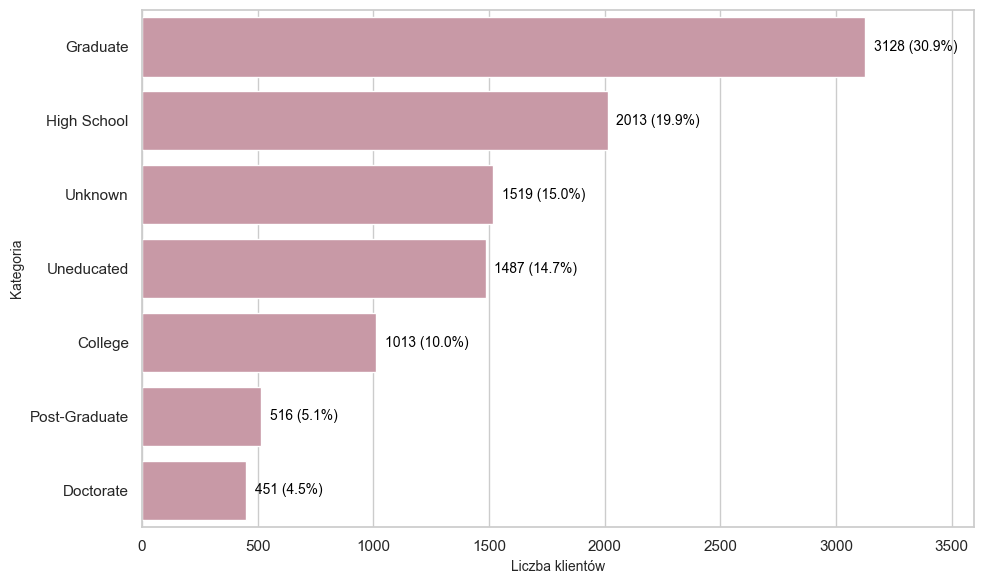

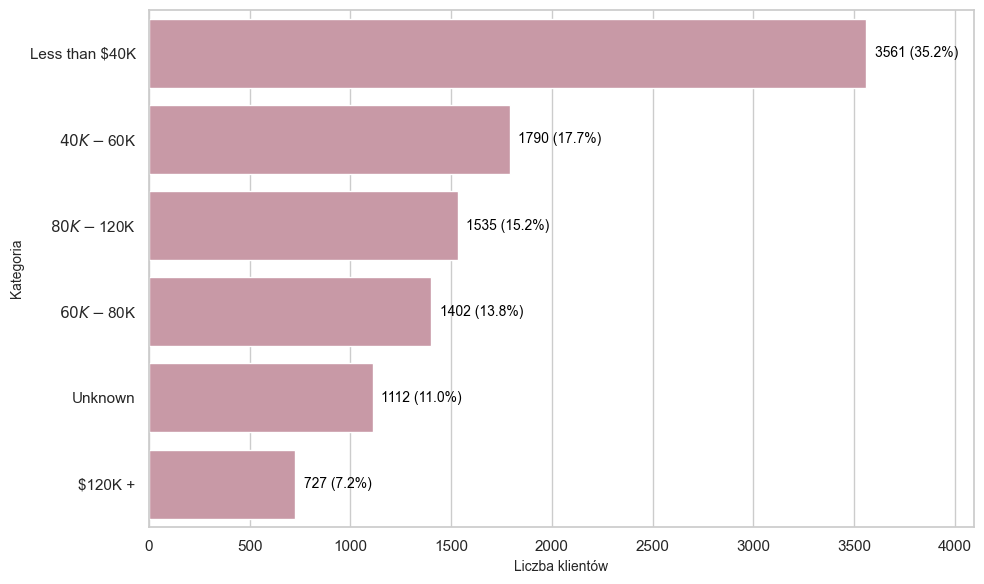

In [ ]:
sns.set_theme(style="whitegrid")

# Wyciągamy jeden ładny, stonowany kolor z naszej jaśniejszej palety cubehelix
base_color = sns.cubehelix_palette(n_colors=5, dark=0.4, light=0.9)[2]

# Generowanie poziomych wykresów słupkowych w pętli

zmienne_slupkowe = ['Education_Level', 'Income_Category']

for kolumna in zmienne_slupkowe:
    plt.figure(figsize=(10, 6)) # Nowy rysunek dla każdej zmiennej
    
    total_count = len(df[kolumna])
    
    # Sortujemy kategorie malejąco według liczebności dla lepszego efektu wizualnego
    order = df[kolumna].value_counts().index
    
    # Używamy parametru 'y' zamiast 'x', co automatycznie tworzy wykres poziomy
    ax = sns.countplot(
        data=df, 
        y=kolumna, 
        order=order,
        color=base_color 
    )
    
    # Zwiększamy limit osi X o 15%, aby zrobić miejsce na tekst po prawej stronie
    max_width = max([p.get_width() for p in ax.patches])
    ax.set_xlim(0, max_width * 1.15) 
    
    # Dodawanie etykiet obok poziomych słupków
    for p in ax.patches:
        count = int(p.get_width()) # Liczebność to teraz SZEROKOŚĆ słupka
        percentage = f'{100 * count / total_count:.1f}%'
        
        # Wyznaczamy środek słupka na osi Y
        center_y = p.get_y() + p.get_height() / 2.
        
        # Tekst w jednej linii, umieszczony tuż za prawą krawędzią słupka
        ax.annotate(f'{count} ({percentage})', 
                    (count, center_y), 
                    ha='left', va='center', # Wyrównanie do lewej strony tekstu, wycentrowane w pionie
                    fontsize=10, color='black', 
                    xytext=(6, 0), # Odsunięcie o 6 punktów w prawo
                    textcoords='offset points')
    
    plt.xlabel('Liczba klientów', fontsize=10)
    plt.ylabel('Kategoria', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Association Between Categorical Variables and Churn

In [ ]:
# Test chi^2 ze zmienną zalezną
from scipy.stats import chi2_contingency

for col in ['Gender', 'Education_Level', 'Marital_Status',
            'Income_Category', 'Card_Category']:
    
    table = pd.crosstab(df[col], df['Attrition_Flag'])
    chi2, p, dof, exp = chi2_contingency(table)
    print(f"{col} p-value = {p:.3f}, chi2 = {chi2:.3f}")

Gender p-value = 0.000, chi2 = 13.866
Education_Level p-value = 0.051, chi2 = 12.511
Marital_Status p-value = 0.109, chi2 = 6.056
Income_Category p-value = 0.025, chi2 = 12.832
Card_Category p-value = 0.525, chi2 = 2.234


At the 5% significance level, the test did not provide sufficient evidence of an association between customer attrition and the variables for which p-values exceeded 0.05 (Card_category and Marital_Status)

# Correlation analysis

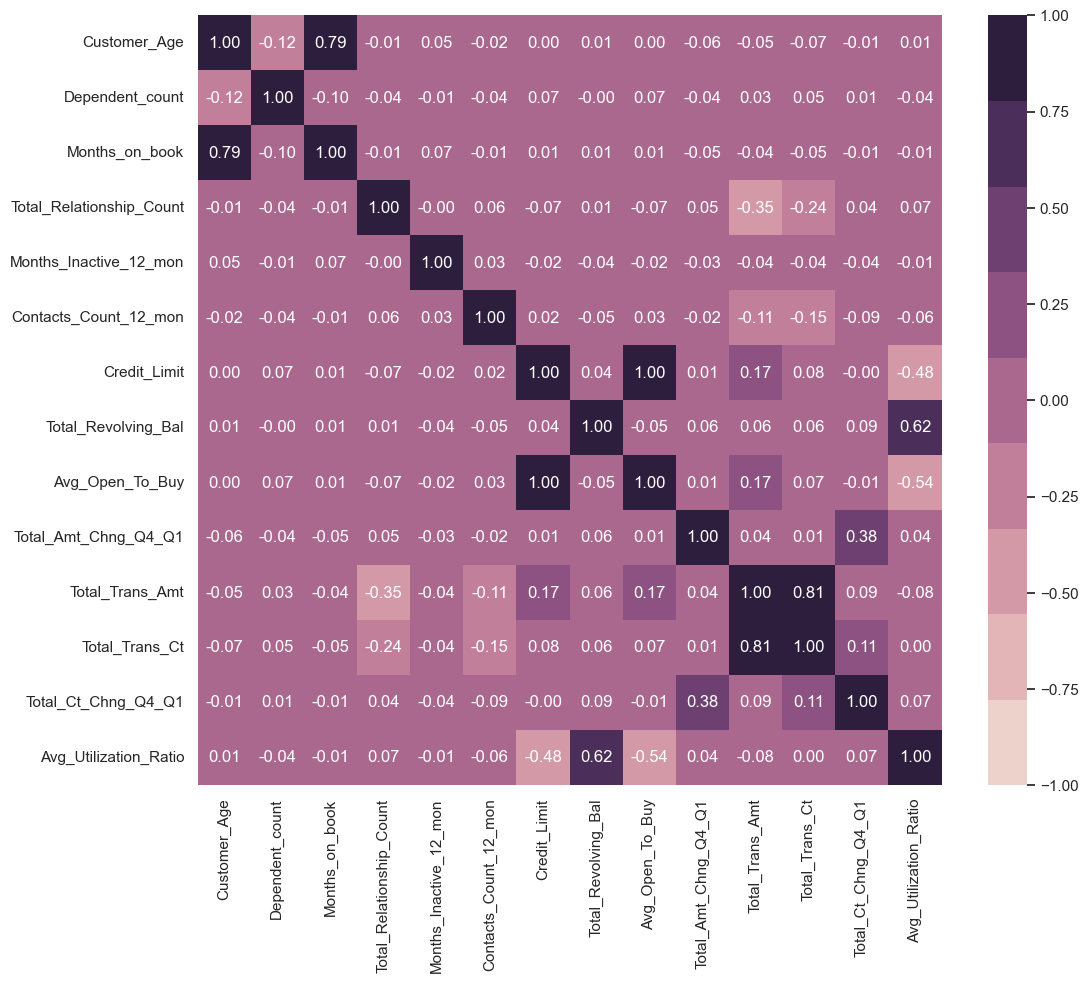

In [41]:
#heatmap korelacji
plt.figure(figsize=(12, 10))
cmap_corr = sns.cubehelix_palette(n_colors=9)
sns.heatmap(df[quant_vars].corr(), annot=True, fmt='.2f',cmap=cmap_corr, vmin=-1, vmax=1)
plt.show()  

To assess feature relationships and identify potential multicollinearity before variable selection and feature engineering:

* **Perfect Multicollinearity (1.00):**  
  `Avg_Open_To_Buy` and `Credit_Limit` share mathematical relationship (Avg_Open_To_Buy = Credit_Limit - Total_Revolving_Bal). One of these features should be dropped or transformed to avoid redundant information.

* **Strong Positive Correlations (0.79):**  
  * **`Total_Trans_Amt` vs. `Total_Trans_Ct` (0.81):** Total transaction volume scales proportionally with transaction frequency.
  * **`Customer_Age` vs. `Months_on_book` (0.79):** Older customers naturally tend to have longer tenure with the bank.

* **Moderate & Domain-Expected Relationships:**  
  * **`Total_Revolving_Bal` vs. `Avg_Utilization_Ratio` (0.62):** Positive alignment between credit utilization and revolving balance without critical collinearity concerns.
  * **`Avg_Utilization_Ratio` vs. `Credit_Limit` / `Avg_Open_To_Buy`:** Shows a moderate negative correlation.

#### Key Takeaways for Feature Selection
* **Multicollinearity Remediation:** Addressing collinear pairs (`Avg_Open_To_Buy` / `Credit_Limit`, transaction metrics, and age/tenure) is essential for linear and distance-based models to ensure coefficient stability and balance feature importance.